In [18]:
import pandas as pd
import numpy as np

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [20]:
import pandas as pd
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [21]:
#Add labels
fake['label'] = 0 # Fake news
true['label'] = 1 # True news
#combine datasets
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1).reset_index(drop=True) # Shuffle the data
#Quick look
data.head()

,title,text,subject,date,label
0,"Undeterred By Threats Of GOP Obstruction, Oba...",President Obama is clearly not letting GOP thr...,News,"March 9, 2016",0
1,House tax panel chair says expects vote on pla...,WASHINGTON (Reuters) - U.S. House Republicans ...,politicsNews,"November 7, 2017",1
2,BREAKING: TODD PALIN In “Very Serious” Snowmob...,Sarah Palin canceled a campaign stop for Donal...,politics,"Mar 14, 2016",0
3,Trump Supreme Court nominee's confirmation hea...,WASHINGTON (Reuters) - The U.S. Senate Judicia...,politicsNews,"February 16, 2017",1
4,Iraqi parliament votes to remove kirkuk govern...,BAGHDAD (Reuters) - Iraq s parliament voted on...,worldnews,"September 14, 2017",1


In [22]:
#Features and labels
X = data['text']
y = data['label']
#Quick check
print("Number of sample:", len(X))
print("Labels distribution:\n", y.value_counts())

Number of sample: 44898
Labels distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit on the whole dataset (we will split later)
X_tfidf = vectorizer.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (44898, 121689)


In [24]:
from sklearn.model_selection import train_test_split

#Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split( X_tfidf, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 35918
Testing samples: 8980


In [25]:
from sklearn.linear_model import LogisticRegression

#create the model
model = LogisticRegression()

#Train the model
model.fit(X_train, y_train)

print("Model training complete")

Model training complete


Accuracy: 0.983630289532294

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      4695
           1       0.98      0.98      0.98      4285

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



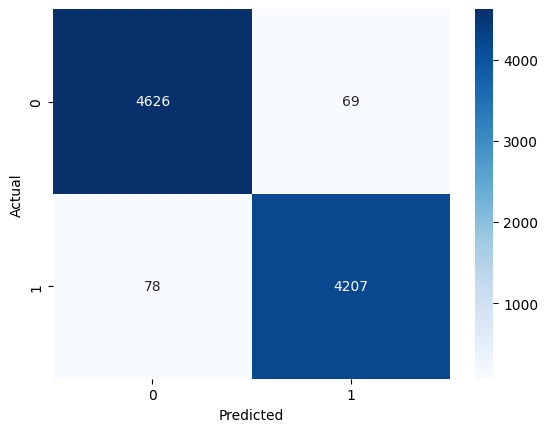

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Make predictions
y_pred = model.predict(X_test)

#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

#Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
#Test custom news
news = ["Officially today is holiday"]

news_vector = vectorizer.transform(news)
prediction = model.predict(news_vector)

if prediction[0] == 1:
  print("Real News")
else:
    print("Fake News")

Fake News
